In [2]:
import pandas as pd
df=pd.read_excel("/content/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
#Understand the data
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [4]:
#check missing values
df.isnull().sum()

#Remove Duplicate rules
df.duplicated().sum()
df.drop_duplicates(inplace=True)

#Handel missing values
df.drop(columns='Description',inplace=True)
df.drop(columns='CustomerID',inplace=True)

#Convert data
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

#Create Date Features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

#Remove negative quantities
df=df[df['Quantity']>0]

#Remove negative or zero prices
df=df[df['UnitPrice']>0]

#remove cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

#Create sales columns
df["Sales"] = df["Quantity"] * df["UnitPrice"]

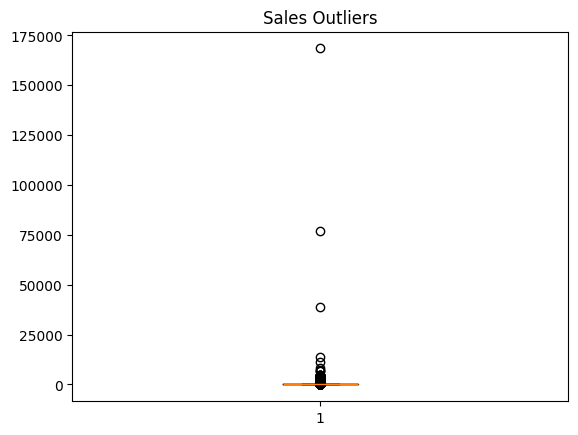

In [5]:
#Check outliers
import matplotlib.pyplot as plt

plt.boxplot(df["Sales"])
plt.title("Sales Outliers")
plt.show()


In [6]:
#Final check
df.info()

df.isnull().sum()

df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Quantity     524878 non-null  int64         
 3   InvoiceDate  524878 non-null  datetime64[ns]
 4   UnitPrice    524878 non-null  float64       
 5   Country      524878 non-null  object        
 6   Year         524878 non-null  int32         
 7   Month        524878 non-null  int32         
 8   Day          524878 non-null  int32         
 9   Weekday      524878 non-null  object        
 10  Hour         524878 non-null  int32         
 11  Sales        524878 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(4), int64(1), object(4)
memory usage: 44.0+ MB


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,Country,Year,Month,Day,Weekday,Hour,Sales
0,536365,85123A,6,2010-12-01 08:26:00,2.55,United Kingdom,2010,12,1,Wednesday,8,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,United Kingdom,2010,12,1,Wednesday,8,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [8]:
#Dataset Overview
print(df.shape)
print(df.columns)
print(df.head())

(524878, 12)
Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'Country', 'Year', 'Month', 'Day', 'Weekday', 'Hour', 'Sales'],
      dtype='object')
  InvoiceNo StockCode  Quantity         InvoiceDate  UnitPrice  \
0    536365    85123A         6 2010-12-01 08:26:00       2.55   
1    536365     71053         6 2010-12-01 08:26:00       3.39   
2    536365    84406B         8 2010-12-01 08:26:00       2.75   
3    536365    84029G         6 2010-12-01 08:26:00       3.39   
4    536365    84029E         6 2010-12-01 08:26:00       3.39   

          Country  Year  Month  Day    Weekday  Hour  Sales  
0  United Kingdom  2010     12    1  Wednesday     8  15.30  
1  United Kingdom  2010     12    1  Wednesday     8  20.34  
2  United Kingdom  2010     12    1  Wednesday     8  22.00  
3  United Kingdom  2010     12    1  Wednesday     8  20.34  
4  United Kingdom  2010     12    1  Wednesday     8  20.34  


In [10]:
#Summary Statistics
df.describe()

#Total sales
total_sales = df["Sales"].sum()
print(f"Total Sales: £{total_sales:,.2f}")

#Total orders
print(df["InvoiceNo"].nunique())

#Total Customers
# print(df["CustomerID"].nunique())

Total Sales: £10,642,110.80
19960


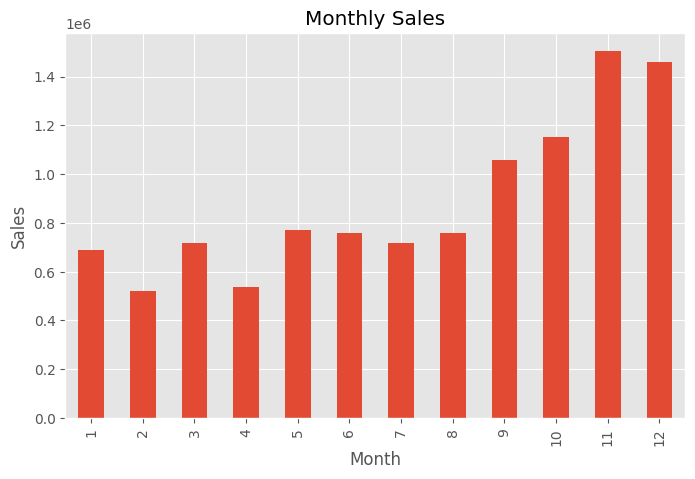

In [11]:
#Sales by month
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(kind="bar", figsize=(8,5))
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

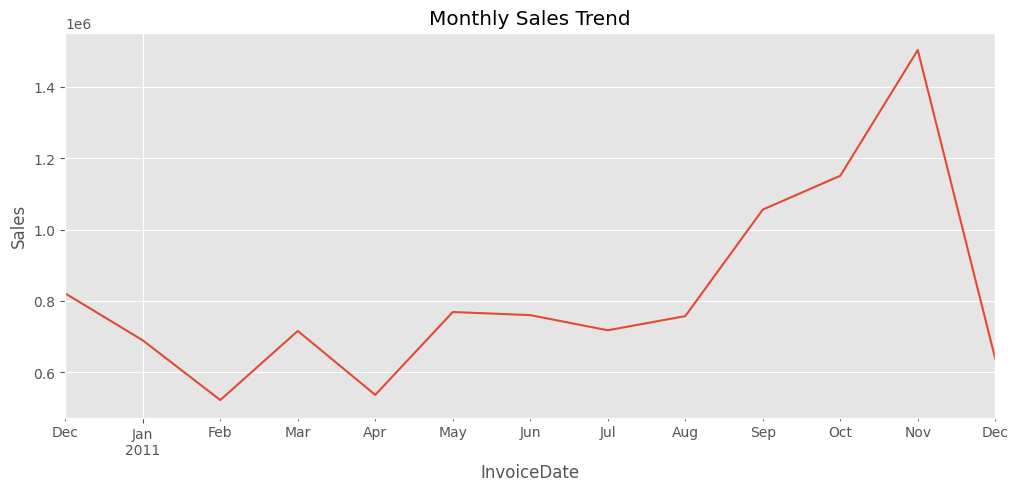

In [12]:
#Monthly sales trend
monthly_trend = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Sales"].sum()

monthly_trend.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

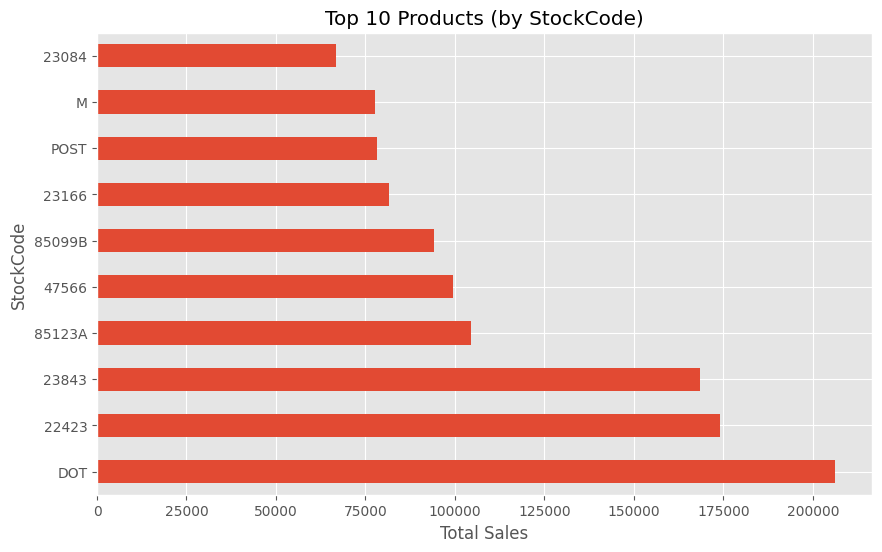

In [14]:
#Top 10 products
top_products = df.groupby("StockCode")["Sales"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products.plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Products (by StockCode)")
plt.xlabel("Total Sales")
plt.ylabel("StockCode")
plt.show()

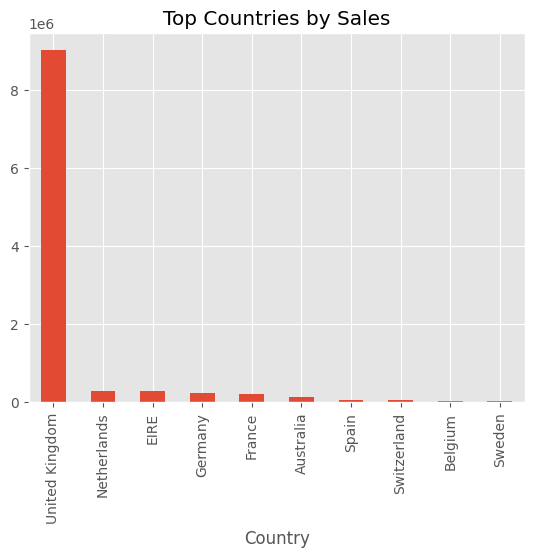

In [15]:
#Top 10 countries
country_sales = df.groupby("Country")["Sales"] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10)

country_sales.plot(kind="bar")
plt.title("Top Countries by Sales")
plt.show()

In [17]:
#Top customers
# top_customers = df.groupby("CustomerID")["Sales"] \
#                   .sum() \
#                   .sort_values(ascending=False) \
#                   .head(10)

# top_customers.plot(kind="bar")
# plt.title("Top Customers")
# plt.show()

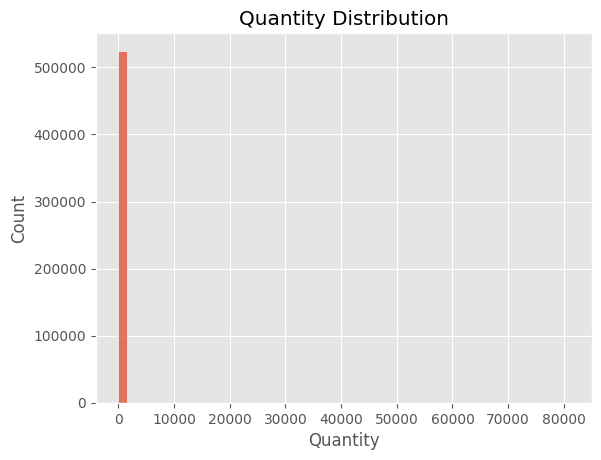

In [18]:
#Quantity distributions
sns.histplot(df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.show()

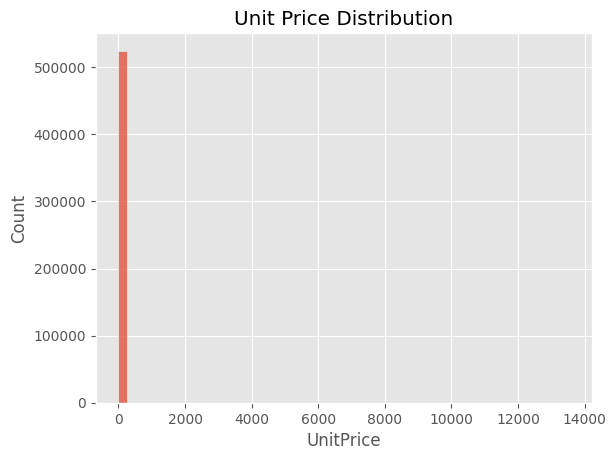

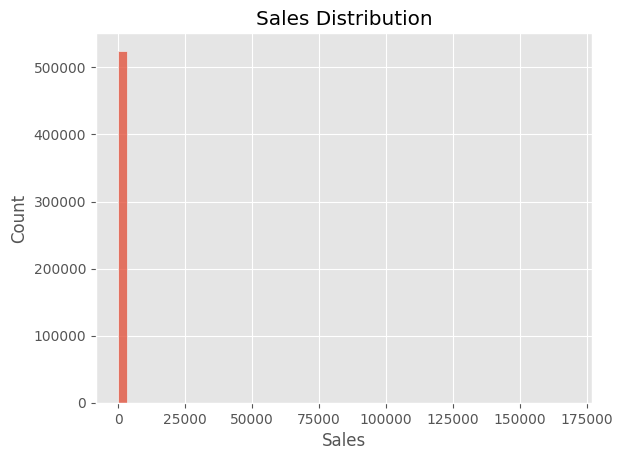

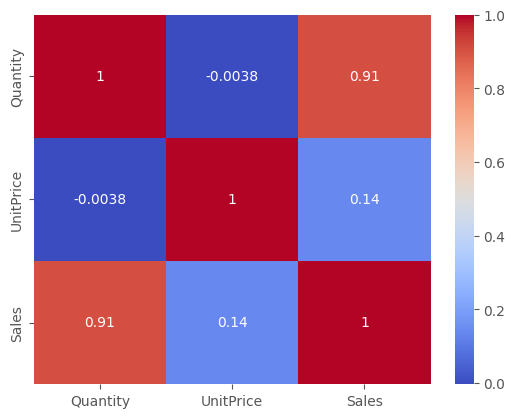

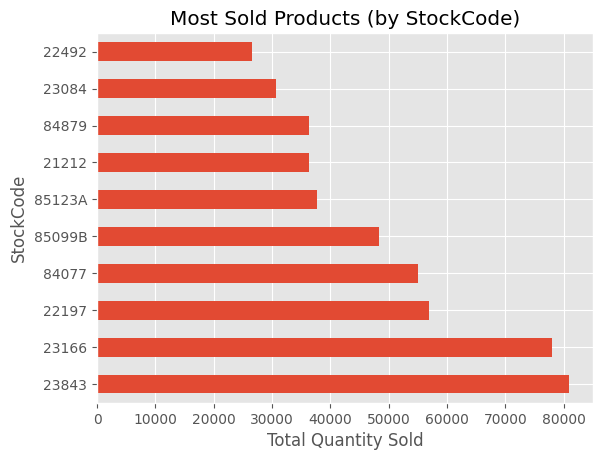

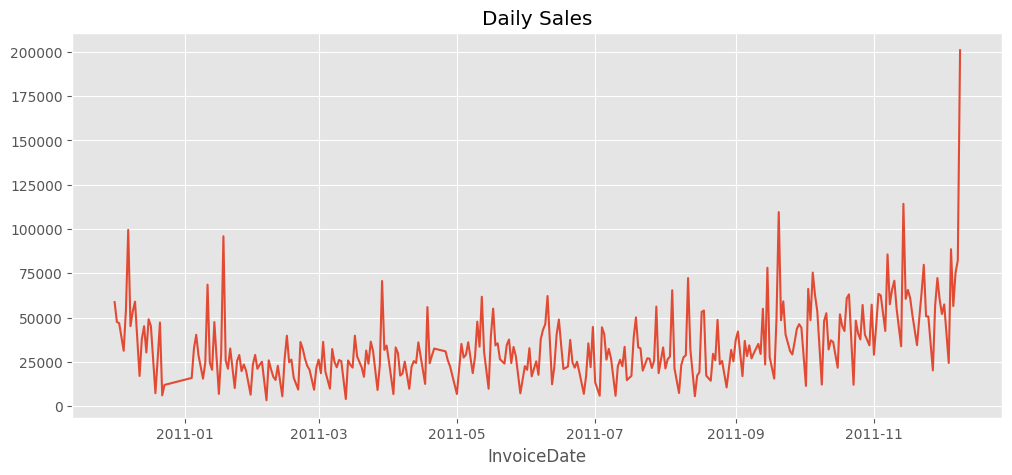

In [20]:
#Unit price Distribution
sns.histplot(df["UnitPrice"], bins=50)
plt.title("Unit Price Distribution")
plt.show()

#Sales Distribution
sns.histplot(df["Sales"], bins=50)
plt.title("Sales Distribution")
plt.show()

#Correlation heatmap
numeric_cols = ["Quantity", "UnitPrice", "Sales"]

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

#Top selling product by quantity
best_qty = df.groupby("StockCode")["Quantity"] \
             .sum() \
             .sort_values(ascending=False) \
             .head(10)

best_qty.plot(kind="barh")
plt.title("Most Sold Products (by StockCode)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("StockCode")
plt.show()

#Daily Sales
daily_sales = df.groupby(df["InvoiceDate"].dt.date)["Sales"].sum()

daily_sales.plot(figsize=(12,5))
plt.title("Daily Sales")
plt.show()

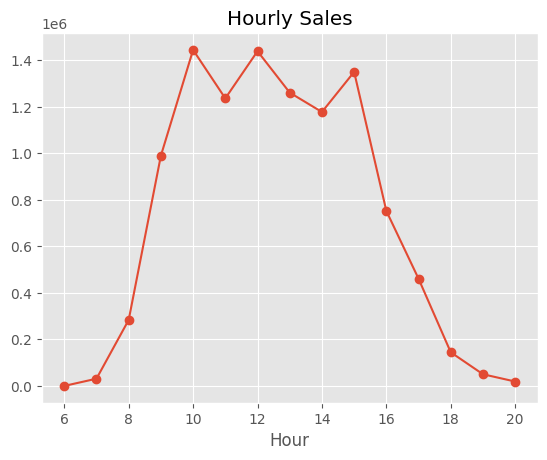

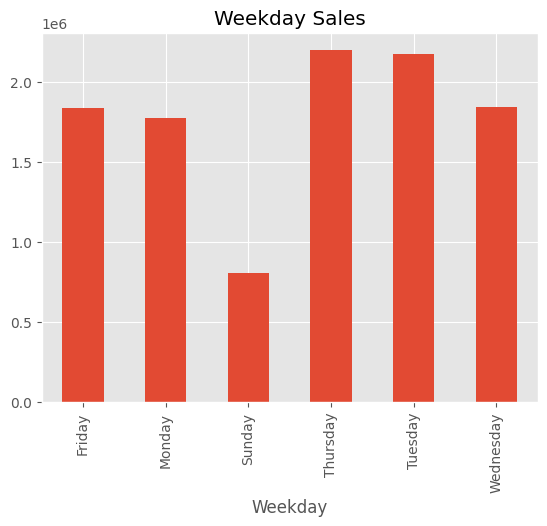

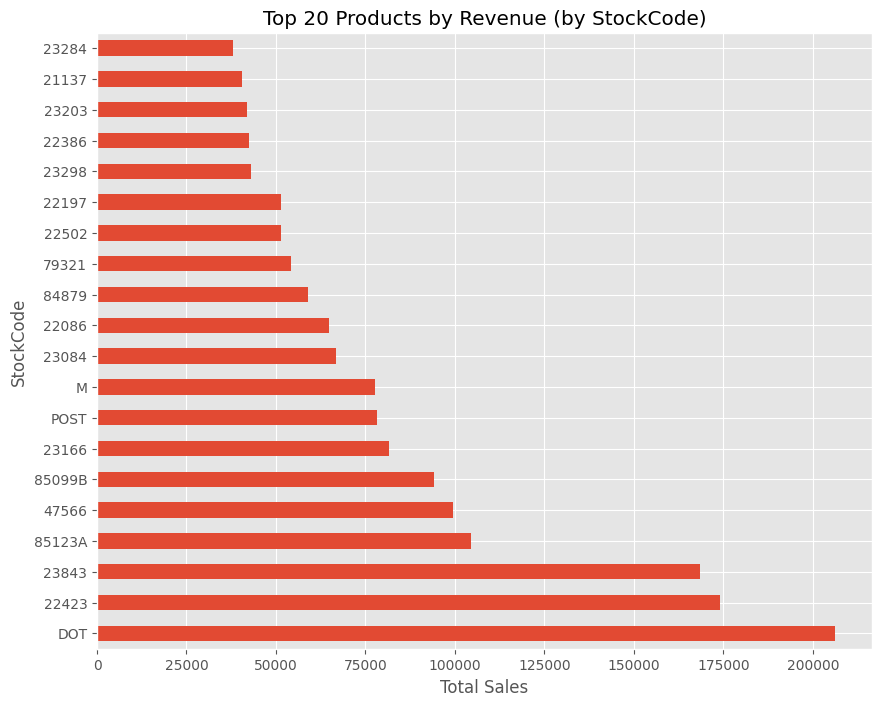

In [23]:
#Hourly Sales
hourly_sales = df.groupby("Hour")["Sales"].sum()

hourly_sales.plot(kind="line", marker="o")
plt.title("Hourly Sales")
plt.show()

#Weekday Sales
weekday_sales = df.groupby("Weekday")["Sales"].sum()

weekday_sales.plot(kind="bar")
plt.title("Weekday Sales")
plt.show()

#Top 20 products by revenue
top20 = df.groupby("StockCode")["Sales"] \
          .sum() \
          .sort_values(ascending=False) \
          .head(20)

top20.plot(kind="barh", figsize=(10,8))
plt.title("Top 20 Products by Revenue (by StockCode)")
plt.xlabel("Total Sales")
plt.ylabel("StockCode")
plt.show()